In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder

import torch
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
from transformers import (MobileBertTokenizer, MobileBertForSequenceClassification,
                          Trainer, TrainingArguments)
from torch.utils.data import Dataset
from scipy.sparse import hstack

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.stem import WordNetLemmatizer

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [1]:
!pip install transformers datasets accelerate -q

## ЭТАП 1: ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

### Описание датасета

Используется датасет **Amazon Reviews** (https://www.kaggle.com/datasets/lievgarcia/amazon-reviews) — 
размеченный набор отзывов с платформы Amazon для задачи выявления поддельных (fake) отзывов.

**Характеристики:**
- 21 000 отзывов (10 500 fake + 10 500 real) — сбалансированный датасет
- 9 колонок: DOC_ID, LABEL, RATING, VERIFIED_PURCHASE, PRODUCT_CATEGORY, PRODUCT_ID, PRODUCT_TITLE, REVIEW_TITLE, REVIEW_TEXT
- 30 категорий товаров (по 700 отзывов в каждой)
- Разметка выполнена Amazon (fake = `__label1__`, real = `__label2__`)

In [3]:
df = pd.read_csv('/kaggle/input/datasets/lievgarcia/amazon-reviews/amazon_reviews.txt', sep='\t')

print(f"Размер датасета: {df.shape}")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print(f"\nКолонки: {list(df.columns)}")
print(f"\nПервые 5 строк:")
df.head()

Размер датасета: (21000, 9)
Количество строк: 21000
Количество столбцов: 9

Колонки: ['DOC_ID', 'LABEL', 'RATING', 'VERIFIED_PURCHASE', 'PRODUCT_CATEGORY', 'PRODUCT_ID', 'PRODUCT_TITLE', 'REVIEW_TITLE', 'REVIEW_TEXT']

Первые 5 строк:


,DOC_ID,LABEL,RATING,VERIFIED_PURCHASE,PRODUCT_CATEGORY,PRODUCT_ID,PRODUCT_TITLE,REVIEW_TITLE,REVIEW_TEXT
0,1,__label1__,4,N,PC,B00008NG7N,"Targus PAUK10U Ultra Mini USB Keypad, Black",useful,"When least you think so, this product will sav..."
1,2,__label1__,4,Y,Wireless,B00LH0Y3NM,Note 3 Battery : Stalion Strength Replacement ...,New era for batteries,Lithium batteries are something new introduced...
2,3,__label1__,3,N,Baby,B000I5UZ1Q,"Fisher-Price Papasan Cradle Swing, Starlight",doesn't swing very well.,I purchased this swing for my baby. She is 6 m...
3,4,__label1__,4,N,Office Products,B003822IRA,Casio MS-80B Standard Function Desktop Calculator,Great computing!,I was looking for an inexpensive desk calcolat...
4,5,__label1__,4,N,Beauty,B00PWSAXAM,Shine Whitening - Zero Peroxide Teeth Whitenin...,Only use twice a week,I only use it twice a week and the results are...


### 1.1 Общая информация о данных

In [4]:
print("Типы данных:")
print(df.dtypes)

print("\nПропуски:")
print(df.isnull().sum())
print(f"Общий процент пропусков: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]):.2%}")

print("\nДубликаты:")
full_dupes = df.duplicated().sum()
text_dupes = df['REVIEW_TEXT'].duplicated().sum()
print(f"Полных дубликатов: {full_dupes}")
print(f"Дубликатов по тексту отзыва: {text_dupes}")

print("\n  статистика числовых признаков:")
print(df.describe())

Типы данных:
DOC_ID                int64
LABEL                object
RATING                int64
VERIFIED_PURCHASE    object
PRODUCT_CATEGORY     object
PRODUCT_ID           object
PRODUCT_TITLE        object
REVIEW_TITLE         object
REVIEW_TEXT          object
dtype: object

Пропуски:
DOC_ID               0
LABEL                0
RATING               0
VERIFIED_PURCHASE    0
PRODUCT_CATEGORY     0
PRODUCT_ID           0
PRODUCT_TITLE        0
REVIEW_TITLE         0
REVIEW_TEXT          0
dtype: int64
Общий процент пропусков: 0.00%

Дубликаты:
Полных дубликатов: 0
Дубликатов по тексту отзыва: 0

  статистика числовых признаков:
             DOC_ID        RATING
count  21000.000000  21000.000000
mean   10500.500000      4.127952
std     6062.322162      1.278333
min        1.000000      1.000000
25%     5250.750000      4.000000
50%    10500.500000      5.000000
75%    15750.250000      5.000000
max    21000.000000      5.000000


### 1.2 Распределение целевой переменной (LABEL)

Распределение классов:
label
fake    10500
real    10500
Name: count, dtype: int64


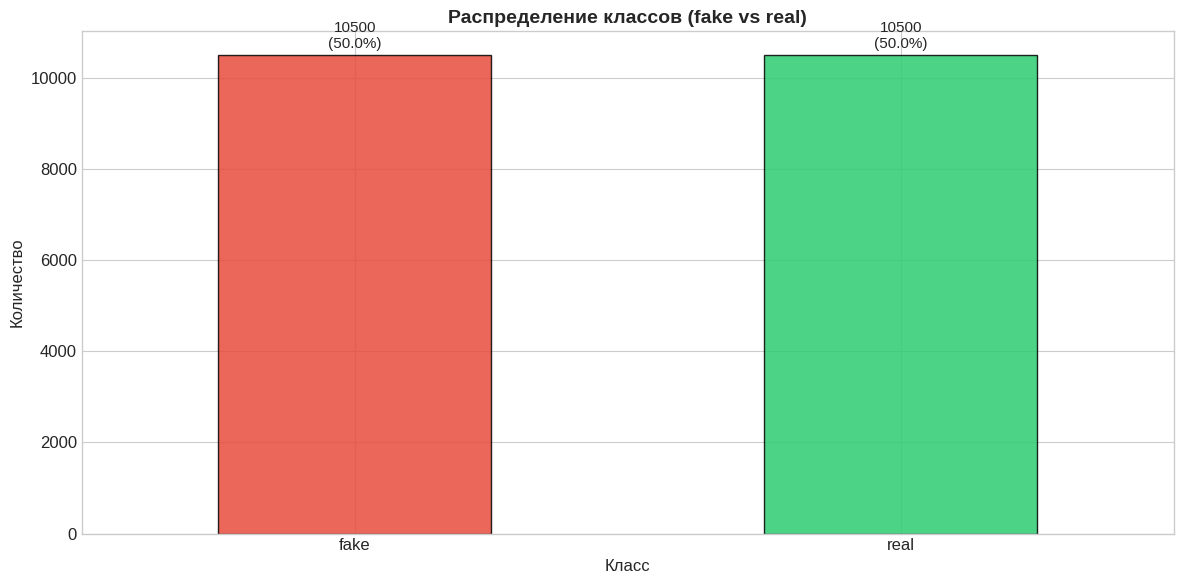

Сохранено: 01_label_distribution.png


In [5]:
df['label'] = df['LABEL'].map({'__label1__': 'fake', '__label2__': 'real'})

print("Распределение классов:")
print(df['label'].value_counts())

fig, ax = plt.subplots()
label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#2ecc71']
label_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.85)
ax.set_title('Распределение классов (fake vs real)', fontsize=14, fontweight='bold')
ax.set_xlabel('Класс')
ax.set_ylabel('Количество')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 150, f'{v}\n({v/len(df):.1%})', ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Сохранено: 01_label_distribution.png")

### 1.3 Анализ признаков по классам

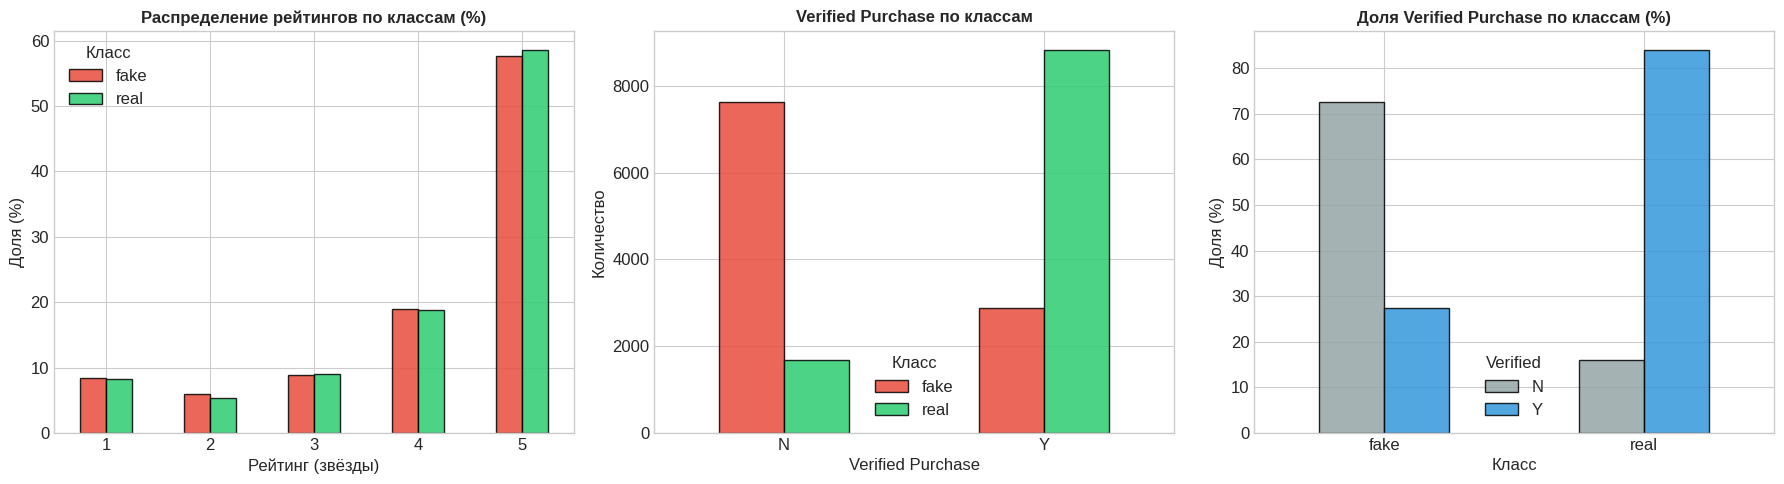

Сохранено: 02_features_by_class.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ct_rating = pd.crosstab(df['RATING'], df['label'], normalize='columns') * 100
ct_rating[['fake', 'real']].plot(kind='bar', ax=axes[0], color=colors, 
                                   edgecolor='black', alpha=0.85)
axes[0].set_title('Распределение рейтингов по классам (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Рейтинг (звёзды)')
axes[0].set_ylabel('Доля (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Класс')

ct_vp = pd.crosstab(df['VERIFIED_PURCHASE'], df['label'])
ct_vp.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black', alpha=0.85)
axes[1].set_title('Verified Purchase по классам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Verified Purchase')
axes[1].set_ylabel('Количество')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Класс')

ct_vp_pct = pd.crosstab(df['label'], df['VERIFIED_PURCHASE'], normalize='index') * 100
ct_vp_pct.plot(kind='bar', ax=axes[2], color=['#95a5a6', '#3498db'],
               edgecolor='black', alpha=0.85)
axes[2].set_title('Доля Verified Purchase по классам (%)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Класс')
axes[2].set_ylabel('Доля (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Verified')

plt.tight_layout()
plt.savefig('02_features_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 02_features_by_class.png")


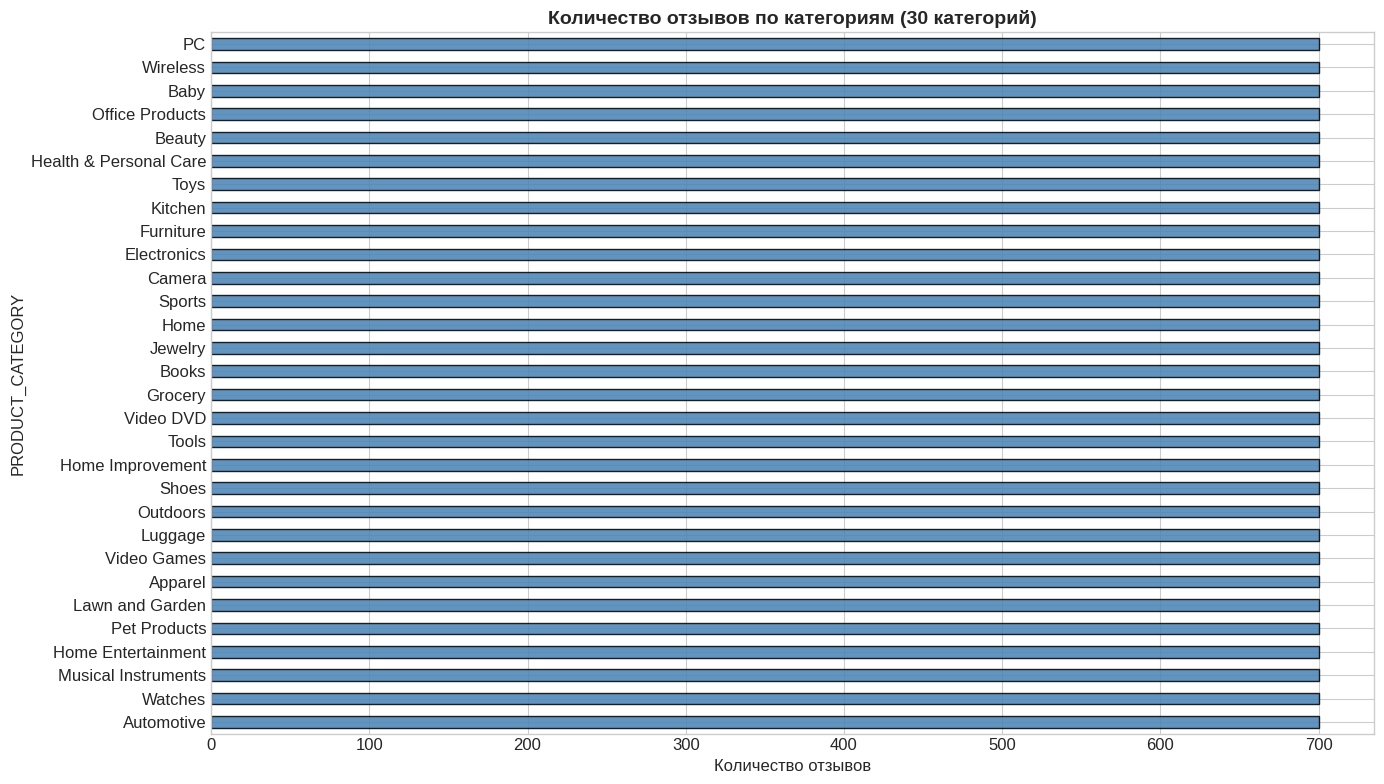

Сохранено: 03_categories_distribution.png

Все 30 категорий содержат по 700 отзывов 


In [7]:
fig, ax = plt.subplots(figsize=(14, 8))
cat_counts = df['PRODUCT_CATEGORY'].value_counts()
cat_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', alpha=0.85)
ax.set_title(f'Количество отзывов по категориям ({df["PRODUCT_CATEGORY"].nunique()} категорий)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Количество отзывов')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('03_categories_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 03_categories_distribution.png")
print(f"\nВсе {df['PRODUCT_CATEGORY'].nunique()} категорий содержат по {cat_counts.iloc[0]} отзывов ")

## ЭТАП 2: ОЧИСТКА И ПРЕДОБРАБОТКА ТЕКСТА

### 2.1 Удаление пропусков и дубликатов

In [8]:
print(f"Размер до очистки: {len(df)}")
df = df[df['REVIEW_TEXT'].str.len() > 10]
print(f"После удаления коротких текстов (<=10 симв.): {len(df)}")

Размер до очистки: 21000
После удаления коротких текстов (<=10 симв.): 21000


### 2.2 Функция очистки текста

In [9]:
stop_words = set(ENGLISH_STOP_WORDS)
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    # HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # URL
    text = re.sub(r'http\S+|www\.\S+', '', text)
     # числа
    text = re.sub(r'\d+', '', text)
    # пунктуация и спецсимволы
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['REVIEW_TEXT'].apply(clean_text)

df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"После очистки текста (итого): {len(df)}")

После очистки текста (итого): 21000


## ЭТАП 3: FEATURE ENGINEERING

In [10]:
df['text_length'] = df['REVIEW_TEXT'].str.len()
df['word_count'] = df['REVIEW_TEXT'].str.split().str.len()
df['avg_word_length'] = df['REVIEW_TEXT'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0)
df['exclamation_count'] = df['REVIEW_TEXT'].str.count('!')
df['question_count'] = df['REVIEW_TEXT'].str.count(r'\?')
df['uppercase_ratio'] = df['REVIEW_TEXT'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1))
df['punctuation_count'] = df['REVIEW_TEXT'].apply(
    lambda x: sum(1 for c in str(x) if c in string.punctuation))
df['title_length'] = df['REVIEW_TITLE'].astype(str).str.len()
df['clean_word_count'] = df['clean_text'].str.split().str.len()
# отношение уникальных слов к общему числу слов
df['lexical_diversity'] = df['REVIEW_TEXT'].apply(
    lambda x: len(set(str(x).lower().split())) / max(len(str(x).lower().split()), 1))
df['is_verified'] = (df['VERIFIED_PURCHASE'] == 'Y').astype(int)

feature_cols = ['text_length', 'word_count', 'avg_word_length', 'exclamation_count',
                'question_count', 'uppercase_ratio', 'punctuation_count',
                'title_length', 'clean_word_count', 'lexical_diversity', 'is_verified']

print(f"Создано {len(feature_cols)} признаков:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nСтатистика признаков:")
print(df[feature_cols].describe().round(2))

Создано 11 признаков:
   1. text_length
   2. word_count
   3. avg_word_length
   4. exclamation_count
   5. question_count
   6. uppercase_ratio
   7. punctuation_count
   8. title_length
   9. clean_word_count
  10. lexical_diversity
  11. is_verified

Статистика признаков:
       text_length  word_count  avg_word_length  exclamation_count  \
count     21000.00    21000.00         21000.00           21000.00   
mean        372.30       69.19             4.36               0.53   
std         480.51       85.90             0.46               1.23   
min          98.00       13.00             3.09               0.00   
25%         156.00       30.00             4.07               0.00   
50%         236.00       45.00             4.31               0.00   
75%         388.00       73.00             4.59               1.00   
max       16188.00     2847.00            13.14              24.00   

       question_count  uppercase_ratio  punctuation_count  title_length  \
count        2100

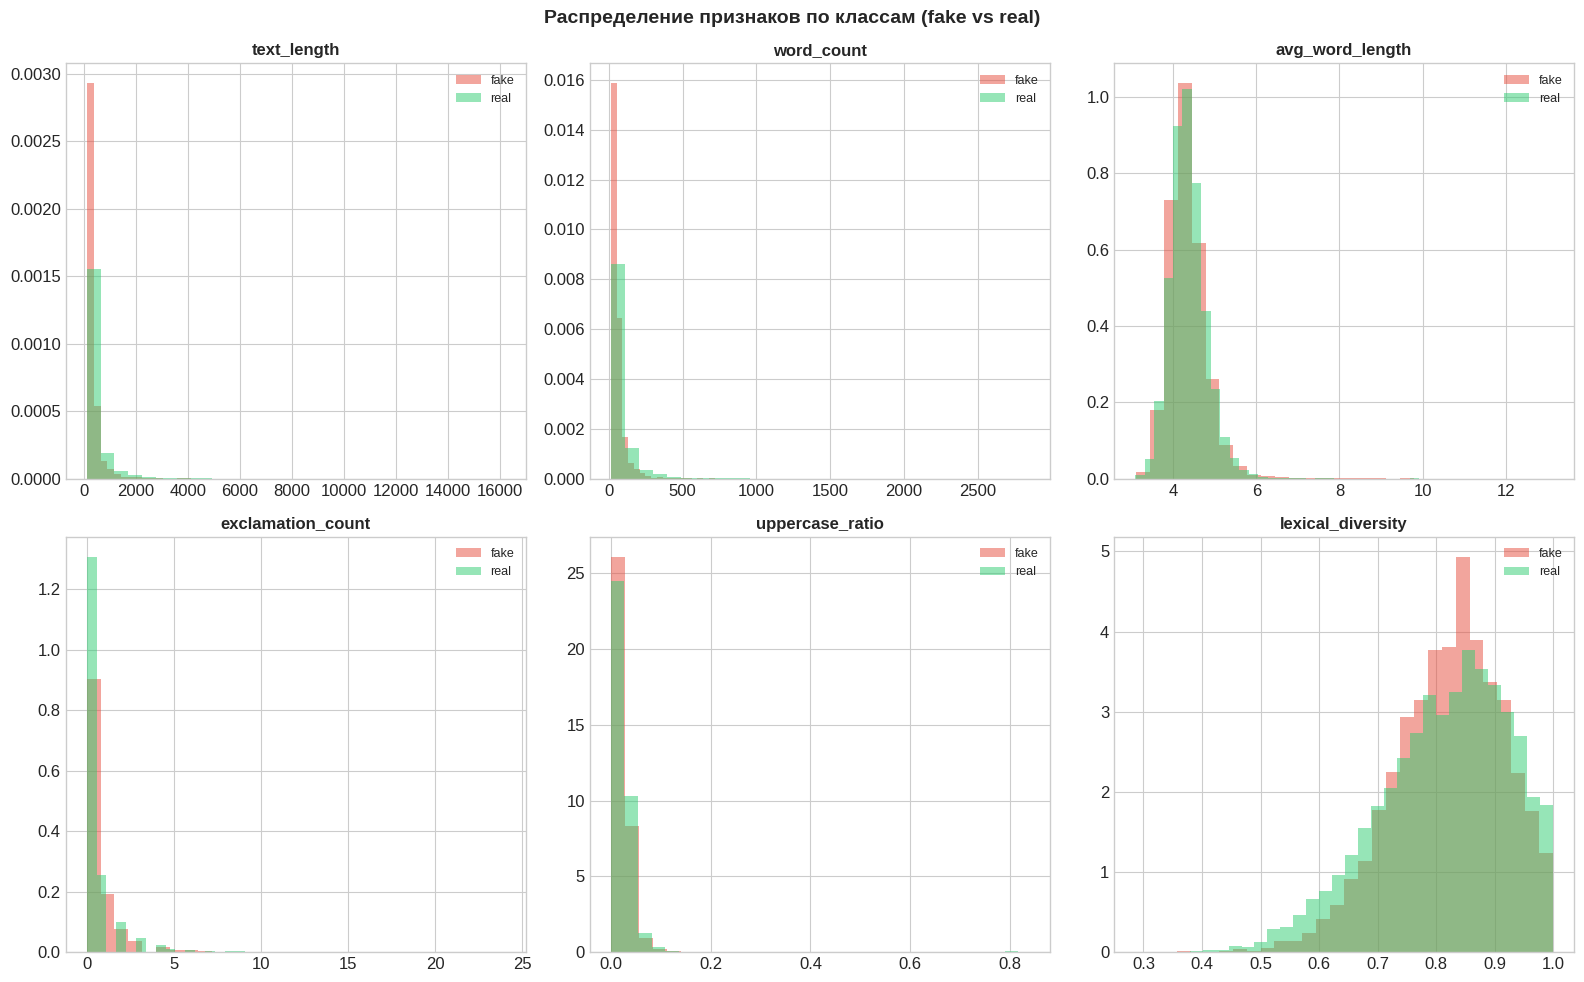

Сохранено: 04_features_by_class.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plot_features = ['text_length', 'word_count', 'avg_word_length',
                 'exclamation_count', 'uppercase_ratio', 'lexical_diversity']

for ax, feat in zip(axes.flat, plot_features):
    for cls, color in zip(['fake', 'real'], ['#e74c3c', '#2ecc71']):
        data = df[df['label'] == cls][feat]
        ax.hist(data, bins=30, alpha=0.5, label=cls, color=color, density=True)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Распределение признаков по классам (fake vs real)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_features_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 04_features_by_class.png")

## ЭТАП 4: ВЕКТОРИЗАЦИЯ ТЕКСТА (TF-IDF)

In [12]:
df['full_text'] = df['REVIEW_TITLE'].astype(str) + ' ' + df['clean_text']

X_text = df['full_text']
y = df['label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Классы: {list(le.classes_)} → {list(range(len(le.classes_)))}")

X_train_text, X_test_text, y_train, y_test, train_idx, test_idx = train_test_split(
    X_text, y_encoded, df.index, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"Размер обучающей выборки: {len(X_train_text)}")
print(f"Размер тестовой выборки:  {len(X_test_text)}")

tfidf = TfidfVectorizer(max_features=15000,
                        ngram_range=(1, 2),
                        min_df=2,
                        max_df=0.95,
                        sublinear_tf=True)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

X_train_extra = df.loc[train_idx, feature_cols].values
X_test_extra = df.loc[test_idx, feature_cols].values

X_train_combined = hstack([X_train_tfidf, X_train_extra])
X_test_combined = hstack([X_test_tfidf, X_test_extra])

print(f"\nРазмер комбинированной матрицы (TF-IDF + {len(feature_cols)} фичей):")
print(f"  Train: {X_train_combined.shape}")
print(f"  Test:  {X_test_combined.shape}")

feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_tfidf.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-20:][::-1]
print("\nТоп-20 слов по среднему TF-IDF:")
for i, idx in enumerate(top_idx, 1):
    print(f"  {i:2d}. {feature_names[idx]:20s} — {mean_tfidf[idx]:.4f}")

Классы: ['fake', 'real'] → [0, 1]
Размер обучающей выборки: 16800
Размер тестовой выборки:  4200

Размер комбинированной матрицы (TF-IDF + 11 фичей):
  Train: (16800, 15011)
  Test:  (4200, 15011)

Топ-20 слов по среднему TF-IDF:
   1. great                — 0.0257
   2. good                 — 0.0208
   3. love                 — 0.0179
   4. like                 — 0.0175
   5. product              — 0.0173
   6. just                 — 0.0163
   7. work                 — 0.0148
   8. really               — 0.0148
   9. use                  — 0.0141
  10. quality              — 0.0141
  11. time                 — 0.0131
  12. price                — 0.0128
  13. nice                 — 0.0124
  14. look                 — 0.0120
  15. easy                 — 0.0113
  16. the                  — 0.0111
  17. bought               — 0.0108
  18. it                   — 0.0104
  19. perfect              — 0.0102
  20. little               — 0.0102


## ЭТАП 5: МОДЕЛИ

### Модель 1: Multinomial Naive Bayes

In [13]:
results = {}

print("Модель 1: Multinomial Naive Bayes")
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
y_prob_nb = nb_model.predict_proba(X_test_tfidf)[:, 1]

nb_acc = accuracy_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

results['Naive Bayes'] = {
    'accuracy': nb_acc,
    'f1_weighted': nb_f1,
    'predictions': y_pred_nb,
    'probabilities': y_prob_nb
}
print(f"Accuracy:    {nb_acc:.4f}")
print(f"F1 (weighted): {nb_f1:.4f}")

Модель 1: Multinomial Naive Bayes
Accuracy:    0.6524
F1 (weighted): 0.6523


### Модель 2: Gradient Boosting

In [24]:
print("Модель 2: Gradient Boosting (TF-IDF + числовые признаки)")
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42,
    max_features='sqrt'
)
gb_model.fit(X_train_combined, y_train)
y_pred_gb = gb_model.predict(X_test_combined)
y_prob_gb = gb_model.predict_proba(X_test_combined)[:, 1]

gb_acc = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb, average='weighted')

results['Gradient Boosting'] = {
    'accuracy': gb_acc,
    'f1_weighted': gb_f1,
    'predictions': y_pred_gb,
    'probabilities': y_prob_gb
}
print(f"Accuracy:    {gb_acc:.4f}")
print(f"F1 (weighted): {gb_f1:.4f}")


Модель 2: Gradient Boosting (TF-IDF + числовые признаки)
Accuracy:    0.8140
F1 (weighted): 0.8137


### Модель 3: MobileBERT (fine-tune)

MobileBERT -  компактная версия BERT, специально разработанная для мобильных устройств и сред с ограниченными ресурсами, создана методом **Progressive Knowledge Transfer** - послойного переноса знаний из большой модели IB-BERT teacher в маленькую MobileBERT student.

**Архитектура MobileBERT:**

| Компонент | MobileBERT | BERT-base |
|-----------|-----------|-----------|
| **Параметры** | ~25M | 110M |
| **Transformer-слои** | 24 | 12 |
| **Hidden Size** | 128 (inter-block: 512) | 768 |
| **Attention Heads** | 4 | 12 |
| **Скорость (относ.)** | 4.3× быстрее BERT | 1× | 

**Ключевые особенности:**
- **Bottleneck-архитектура**: каждый Transformer-блок сжимает вход (128-мерный) → расширяет (512-мерный) → сжимает обратно (128-мерный).
- **24 слоя**, но тонких
- **Предобучение**: модель обучена на тех же данных что BERT (BooksCorpus + Wikipedia, ~3.3млрд слов)
- **В 4.3 раза быстрее BERT**, при этом сохраняет ~96% его качества
- 

**Параметры обучения в нашей работе:**
- Эпохи: 3
- Batch size: 32 (train) / 64 (eval)
- Learning rate warmup: 300 шагов
- Weight decay: 0.01
- Max sequence length: 128 токенов

In [15]:
train_texts = df.loc[train_idx, 'REVIEW_TEXT'].tolist()
test_texts = df.loc[test_idx, 'REVIEW_TEXT'].tolist()
train_labels = y_train.tolist()
test_labels = y_test.tolist()

print(f"Классы: {list(le.classes_)}")
print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")

tokenizer = MobileBertTokenizer.from_pretrained('google/mobilebert-uncased')
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

model = MobileBertForSequenceClassification.from_pretrained(
    'google/mobilebert-uncased', num_labels=len(le.classes_))

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    warmup_steps=300,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    fp16=True,
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='weighted')
    return {'accuracy': acc, 'f1_weighted': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

trainer.train()

print("\nПолучение предсказаний MobileBERT на тестовой выборке")
preds_output = trainer.predict(test_dataset)
y_pred_mb = preds_output.predictions.argmax(-1)

mb_probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()[:, 1]

mb_acc = accuracy_score(y_test, y_pred_mb)
mb_f1 = f1_score(y_test, y_pred_mb, average='weighted')

results['MobileBERT'] = {
    'accuracy': mb_acc,
    'f1_weighted': mb_f1,
    'predictions': y_pred_mb,
    'probabilities': mb_probs
}

print(f"\nМодель 3: MobileBERT")
print(f"Accuracy:    {mb_acc:.4f}")
print(f"F1 (weighted): {mb_f1:.4f}")

Классы: ['fake', 'real']
Train: 16800, Test: 4200


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/847 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/147M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['mobilebert.embeddings.LayerNorm.bias', 'mobilebert.embeddings.LayerNorm.weight', 'mobilebert.encoder.layer.0.attention.output.LayerNorm.bias', 'mobilebert.encoder.layer.0.attention.output.LayerNorm.weight', 'mobilebert.encoder.layer.0.output.LayerNorm.bias', 'mobilebert.encoder.layer.0.output.LayerNorm.weight', 'mobilebert.encoder.layer.0.output.bottleneck.LayerNorm.bias', 'mobilebert.encoder.layer.0.output.bottleneck.LayerNorm.weight', 'mobilebert.encoder.layer.0.bottleneck.input.LayerNorm.bias', 'mobilebert.encoder.layer.0.bottleneck.input.LayerNorm.weight', 'mobilebert.encoder.layer.0.bottleneck.attention.LayerNorm.bias', 'mobilebert.encoder.layer.0.bottleneck.attention.LayerNorm.weight', 'mobilebert.encoder.layer.0.ffn.0.output.LayerNorm.bias', 'mobilebert.encoder.layer.0.ffn.0.output.LayerNorm.weight', 'mobilebert.encoder.layer.0.ffn.1.output.LayerNorm.bias', 'mobilebert.encoder.layer.0.ffn.1.output.LayerNorm.weight', 'mobi


Получение предсказаний MobileBERT на тестовой выборке



Модель 3: MobileBERT
Accuracy:    0.6962
F1 (weighted): 0.6960


## ЭТАП 6: МЕТРИКИ

  Naive Bayes

              precision    recall  f1-score   support

        fake       0.66      0.64      0.65      2100
        real       0.65      0.67      0.66      2100

    accuracy                           0.65      4200
   macro avg       0.65      0.65      0.65      4200
weighted avg       0.65      0.65      0.65      4200

  Gradient Boosting

              precision    recall  f1-score   support

        fake       0.84      0.77      0.81      2100
        real       0.79      0.86      0.82      2100

    accuracy                           0.81      4200
   macro avg       0.82      0.81      0.81      4200
weighted avg       0.82      0.81      0.81      4200

  MobileBERT

              precision    recall  f1-score   support

        fake       0.69      0.72      0.70      2100
        real       0.71      0.67      0.69      2100

    accuracy                           0.70      4200
   macro avg       0.70      0.70      0.70      4200
weighted avg       0.70 

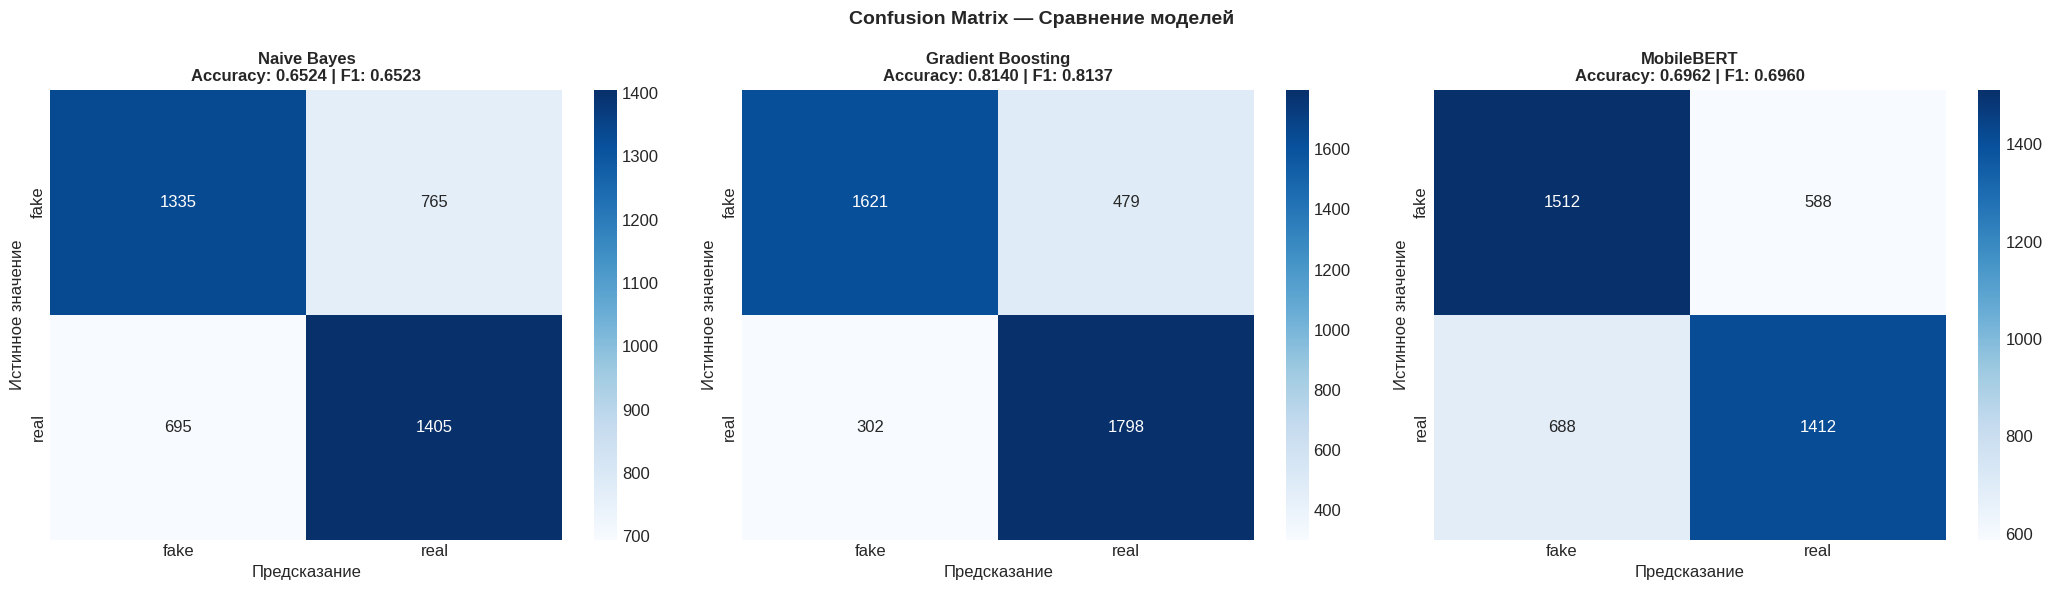

Сохранено: 05_confusion_matrices.png

Сравнительная таблица моделей:
            Model  Accuracy  F1 (weighted)  Precision (weighted)  Recall (weighted)
      Naive Bayes  0.652381       0.652284              0.652550           0.652381
Gradient Boosting  0.814048       0.813717              0.816295           0.814048
       MobileBERT  0.696190       0.696018              0.696636           0.696190


In [16]:
class_names = list(le.classes_)

for name, res in results.items():
    print(f"  {name}")
    print()
    print(classification_report(y_test, res['predictions'], target_names=class_names))

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.4f} | F1: {res["f1_weighted"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Предсказание')
    ax.set_ylabel('Истинное значение')

plt.suptitle('Confusion Matrix — Сравнение моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 05_confusion_matrices.png")

print("\nСравнительная таблица моделей:")
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'F1 (weighted)': [r['f1_weighted'] for r in results.values()],
    'Precision (weighted)': [precision_score(y_test, r['predictions'], average='weighted')
                             for r in results.values()],
    'Recall (weighted)': [recall_score(y_test, r['predictions'], average='weighted')
                          for r in results.values()],
})
print(comparison.to_string(index=False))


## ЭТАП 7: БИЗНЕС-МЕТРИКИ ВЫЯВЛЕНИЯ ПОДДЕЛЬНЫХ ОТЗЫВОВ

### Описание бизнес-метрик и формулы расчёта

| # | Метрика | Формула | Что показывает |
|---|---------|---------|----------------|
| 1 | **Fake Review Detection Accuracy** | `Accuracy = (TP + TN) / (TP + TN + FP + FN)` | Общая доля правильно классифицированных отзывов |
| 2 | **Precision** | `Precision = TP / (TP + FP)` | Из всех отзывов, помеченных как fake, сколько действительно fake |
| 3 | **Recall (Полнота)** | `Recall = TP / (TP + FN)` | Какую долю реальных fake-отзывов система обнаружила |
| 4 | **F1-Score** | `F1 = 2 × (Precision × Recall) / (Precision + Recall)` | Баланс точности и полноты |
| 5 | **AUC-ROC** | Площадь под ROC-кривой | Способность модели разделять классы при разных порогах |
| 6 | **False Positive Rate (FPR)** | `FPR = FP / (FP + TN)` | Доля настоящих отзывов, ошибочно помеченных как fake |
| 7 | **Specificity** | `Specificity = TN / (TN + FP)` | Доля реальных отзывов, правильно распознанных как real |
| 8 | **False Omission Rate (FOR)** | `FOR = FN / (FN + TN)` | Доля fake-отзывов, пропущенных среди всех «пропущенных» |

Где: TP = True Positive (fake правильно выявлен), TN = True Negative (real правильно распознан), FP = False Positive (real ошибочно помечен как fake), FN = False Negative (fake пропущен)

In [17]:

best_name = max(results, key=lambda k: results[k]['f1_weighted'])
print(f"Лучшая модель: {best_name}\n")

print("БИЗНЕС-МЕТРИКИ ВЫЯВЛЕНИЯ ПОДДЕЛЬНЫХ ОТЗЫВОВ")

business_metrics = []

for name, res in results.items():
    preds = res['predictions']
    cm = confusion_matrix(y_test, preds)
    
    # Для бинарной: fake=0, real=1 (по LabelEncoder: fake < real)
    tn, fp, fn, tp = cm.ravel()
    
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    for_rate = fn / (fn + tn) if (fn + tn) > 0 else 0
    
    # AUC-ROC
    if 'probabilities' in res:
        auc = roc_auc_score(y_test, res['probabilities'])
    else:
        auc = 0
    
    print(f"\n  {name}:")
    print(f"    Fake Detection Accuracy : {acc:.4f}")
    print(f"    Precision               : {prec:.4f}")
    print(f"    Recall                  : {rec:.4f}")
    print(f"    F1-Score                : {f1:.4f}")
    print(f"    AUC-ROC                 : {auc:.4f}")
    print(f"    False Positive Rate     : {fpr:.4f}")
    print(f"    Specificity             : {specificity:.4f}")
    print(f"    False Omission Rate     : {for_rate:.4f}")
    
    business_metrics.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'AUC-ROC': auc,
        'FPR': fpr, 'Specificity': specificity, 'FOR': for_rate
    })

bm_df = pd.DataFrame(business_metrics)
print("\n\nСводная таблица бизнес-метрик:")
print(bm_df.to_string(index=False))

Лучшая модель: Gradient Boosting

БИЗНЕС-МЕТРИКИ ВЫЯВЛЕНИЯ ПОДДЕЛЬНЫХ ОТЗЫВОВ

  Naive Bayes:
    Fake Detection Accuracy : 0.6524
    Precision               : 0.6475
    Recall                  : 0.6690
    F1-Score                : 0.6581
    AUC-ROC                 : 0.7152
    False Positive Rate     : 0.3643
    Specificity             : 0.6357
    False Omission Rate     : 0.3424

  Gradient Boosting:
    Fake Detection Accuracy : 0.8140
    Precision               : 0.7896
    Recall                  : 0.8562
    F1-Score                : 0.8216
    AUC-ROC                 : 0.8762
    False Positive Rate     : 0.2281
    Specificity             : 0.7719
    False Omission Rate     : 0.1570

  MobileBERT:
    Fake Detection Accuracy : 0.6962
    Precision               : 0.7060
    Recall                  : 0.6724
    F1-Score                : 0.6888
    AUC-ROC                 : 0.7732
    False Positive Rate     : 0.2800
    Specificity             : 0.7200
    False Omission

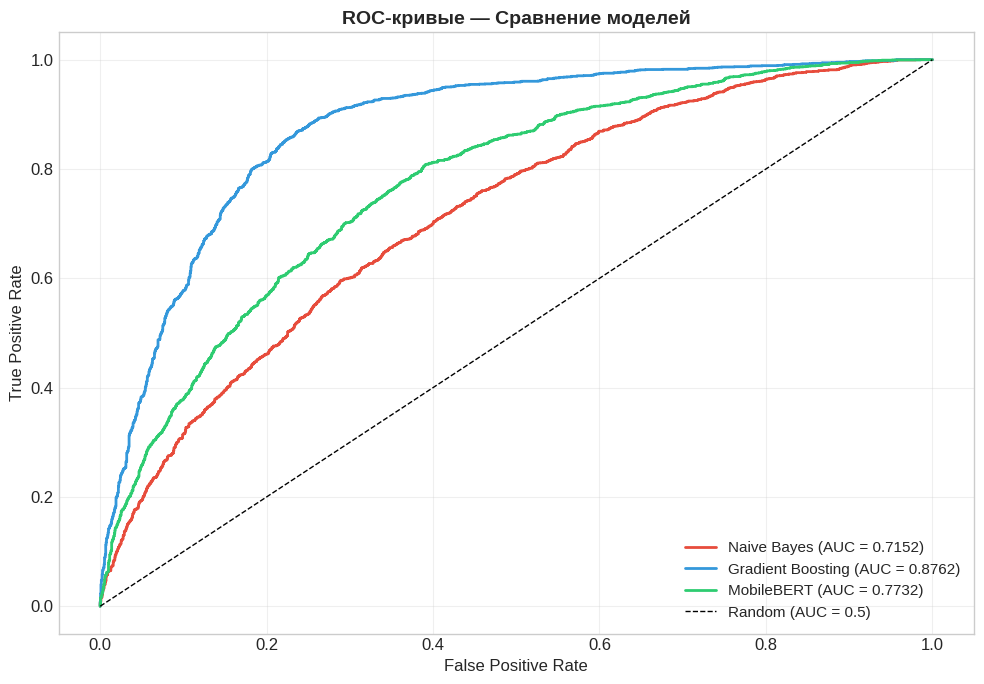

Сохранено: 07_roc_curves.png


In [18]:
# ROC-кривые для моделей с вероятностями
fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

for (name, res), color in zip(results.items(), colors_roc):
    if 'probabilities' in res:
        fpr_vals, tpr_vals, _ = roc_curve(y_test, res['probabilities'])
        auc_val = roc_auc_score(y_test, res['probabilities'])
        ax.plot(fpr_vals, tpr_vals, color=color, linewidth=2,
                label=f'{name} (AUC = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC-кривые — Сравнение моделей', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('07_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 07_roc_curves.png")

## ЭТАП 8: ДОПОЛНИТЕЛЬНАЯ ВИЗУАЛИЗАЦИЯ

### 8.1 Топ-слова для fake и real отзывов

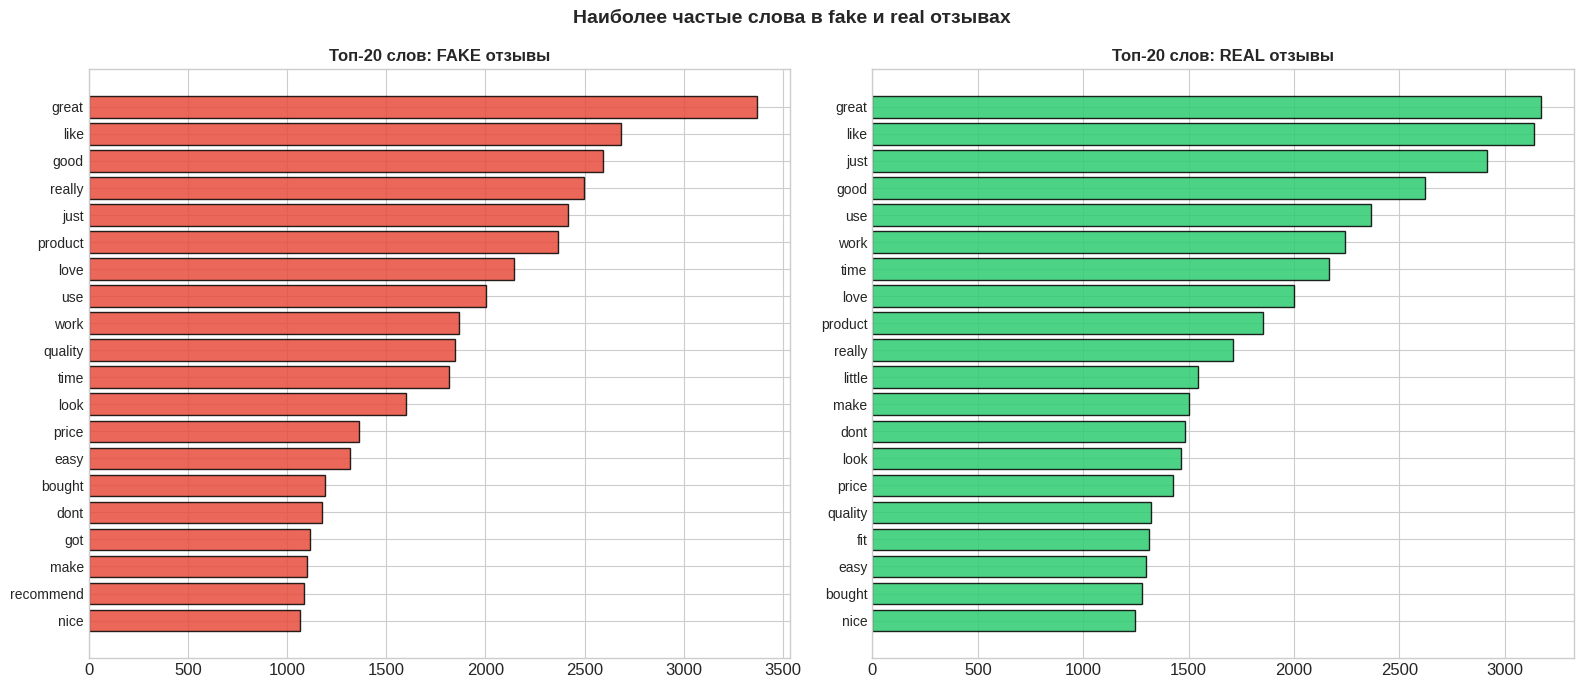

Сохранено: 08_top_words_by_class.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
classes = ['fake', 'real']
colors_cls = ['#e74c3c', '#2ecc71']

for ax, cls, color in zip(axes, classes, colors_cls):
    texts = df[df['label'] == cls]['clean_text']
    word_freq = {}
    for text in texts:
        for word in str(text).split():
            word_freq[word] = word_freq.get(word, 0) + 1
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
    words, counts = zip(*top_words) if top_words else ([], [])

    ax.barh(range(len(words)), counts, color=color, alpha=0.85, edgecolor='black')
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.set_title(f'Топ-20 слов: {cls.upper()} отзывы', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Наиболее частые слова в fake и real отзывах', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_top_words_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 08_top_words_by_class.png")

### 8.2 Корреляция признаков

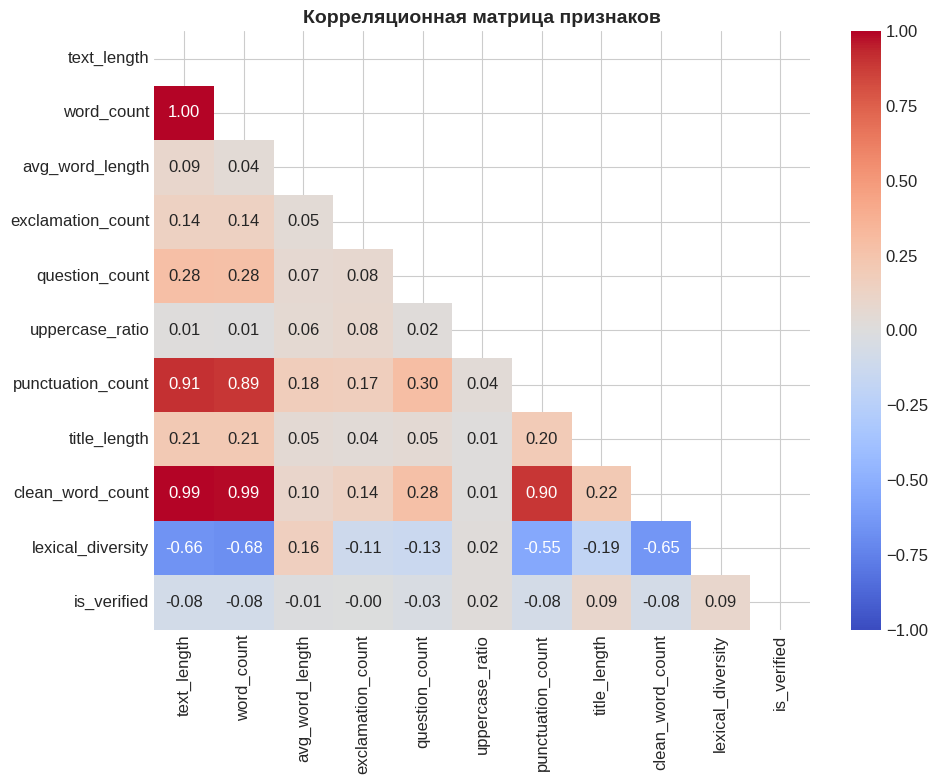

Сохранено: 09_correlation_matrix.png


In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, vmin=-1, vmax=1, center=0)
ax.set_title('Корреляционная матрица признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('09_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 09_correlation_matrix.png")